# 03 — Uji Asap Chronos-2

**Skripsi:** Implementasi *Time Series Foundation Model* Chronos-2 untuk Peramalan Probabilistik Harga Perak dengan Variabel Kovariat Harga Emas dan Dollar Index

Notebook ini dijalankan **sebelum** `src/forecasting.py` ditulis. Tujuannya satu: memverifikasi API AutoGluon-TimeSeries secara langsung, supaya modul pipeline tidak dibangun di atas dugaan yang salah. Chronos-2 dan AutoGluon-TimeSeries masih berkembang cepat, sehingga nama parameter dan perilaku bawaannya wajib diperiksa langsung pada versi yang benar-benar terpasang, bukan disalin dari dokumentasi versi lain.

**Batasan:**

- Data uji **tidak disentuh sama sekali**. Jendela yang dipakai berasal dari periode validasi: konteks berakhir di hari terakhir data latih, target adalah hari-hari pertama periode validasi.
- Notebook ini bersifat eksploratif. Temuannya dirangkum di bagian 9 sebagai spesifikasi yang harus dipatuhi `src/forecasting.py`.

**Ringkasan temuan** (rincian di bagian 9) — empat hal berbeda dari dugaan awal dan berdampak langsung pada desain pipeline:

1. `TimeSeriesDataFrame.freq` bernilai `None`; AutoGluon **menolak** melakukan fit tanpa frekuensi.
2. Kalender prediksi (hari bisnis) tidak sejajar dengan kalender aktual (hari perdagangan).
3. `fine_tune_mode` hanya menerima `"full"` atau `"lora"` — nilai `"linear_probe"` pada `config.yaml` tidak valid.
4. `random_seed` bawaan `fit()` dan `predict()` adalah `123`, bukan `42`.

In [ ]:
import inspect
import io
import json
import logging
import sys
import time
from pathlib import Path

# Tambahkan akar project ke sys.path agar `import src.*` bekerja dari folder notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.data_collection import DATE_INDEX_NAME
from src.preprocessing import (
    get_covariate_columns,
    get_target_column,
    to_timeseries_dataframe,
)
from src.utils import load_config, resolve_path

%matplotlib inline

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["savefig.bbox"] = "tight"
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

CONFIG = load_config()
TARGET_COL = get_target_column(CONFIG)
COVARIATE_COLS = get_covariate_columns(CONFIG)
HORIZON = CONFIG["model"]["prediction_length"]
QUANTILE_LEVELS = CONFIG["model"]["quantile_levels"]
MAX_CONTEXT = CONFIG["model"]["max_context"]
SEED = CONFIG["seed"]

FIGURES_DIR = resolve_path(CONFIG["paths"]["figures_dir"]) / "smoke_test"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PREDICTOR_PATH = resolve_path(CONFIG["paths"]["models_dir"]) / "smoke_test_chronos2"

print("Target        :", TARGET_COL)
print("Kovariat      :", COVARIATE_COLS)
print("Horizon H     :", HORIZON)
print("max_context   :", MAX_CONTEXT)
print("seed          :", SEED)
print("Kuantil (K)   :", len(QUANTILE_LEVELS))

## 1. Versi library dan ketersediaan perangkat

Yang diperiksa: versi `autogluon.timeseries`, versi `torch`, dan apakah GPU dapat dipakai. Perhatikan bahwa `torch.cuda.is_available()` bisa bernilai `False` karena **dua sebab berbeda** — tidak ada GPU sama sekali, atau GPU ada tetapi `torch` yang terpasang adalah build khusus CPU. Keduanya dibedakan di sel berikut, karena implikasinya sangat berbeda.

In [2]:
import autogluon.timeseries as ag
import torch
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor
from autogluon.timeseries.models import Chronos2Model

print("autogluon.timeseries :", ag.__version__)
print("torch                :", torch.__version__)
print("torch.cuda.is_available():", torch.cuda.is_available())
print("versi CUDA pada build torch:", torch.version.cuda)
print()

# Membedakan "tidak ada GPU" dari "GPU ada tapi build torch salah"
build_is_cpu_only = torch.version.cuda is None
print("Build torch tanpa dukungan CUDA :", build_is_cpu_only)

if build_is_cpu_only:
    print()
    print("CATATAN: build torch ini CPU-only, sehingga GPU tidak akan terpakai")
    print("apa pun perangkat kerasnya. Periksa keberadaan GPU fisik lewat")
    print("`nvidia-smi` di terminal; bila ada, pasang ulang torch versi CUDA.")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print()
print("Perangkat yang akan dipakai Chronos-2:", DEVICE)

autogluon.timeseries : 1.6.1
torch                : 2.13.0+cpu
torch.cuda.is_available(): False
versi CUDA pada build torch: None

Build torch tanpa dukungan CUDA : True

CATATAN: build torch ini CPU-only, sehingga GPU tidak akan terpakai
apa pun perangkat kerasnya. Periksa keberadaan GPU fisik lewat
`nvidia-smi` di terminal; bila ada, pasang ulang torch versi CUDA.

Perangkat yang akan dipakai Chronos-2: cpu


## 2. Signature API

Dicetak langsung dari objeknya lewat `inspect.signature`, bukan dari ingatan atau dokumentasi versi lain. Perhatikan khususnya nilai bawaan `random_seed`.

In [3]:
for label, function in (
    ("TimeSeriesPredictor.__init__", TimeSeriesPredictor.__init__),
    ("TimeSeriesPredictor.fit", TimeSeriesPredictor.fit),
    ("TimeSeriesPredictor.predict", TimeSeriesPredictor.predict),
):
    print("=" * 78)
    print(label)
    print("=" * 78)
    for name, parameter in inspect.signature(function).parameters.items():
        if name == "self":
            continue
        default = (
            "<wajib>" if parameter.default is inspect.Parameter.empty
            else repr(parameter.default)
        )
        print(f"  {name:28} = {default}")
    print()

TimeSeriesPredictor.__init__
  target                       = None
  known_covariates_names       = None
  prediction_length            = 1
  freq                         = None
  eval_metric                  = None
  eval_metric_seasonal_period  = None
  horizon_weight               = None
  path                         = None
  verbosity                    = 2
  log_to_file                  = True
  log_file_path                = 'auto'
  quantile_levels              = None
  cache_predictions            = False
  label                        = None
  kwargs                       = <wajib>

TimeSeriesPredictor.fit
  train_data                   = <wajib>
  tuning_data                  = None
  time_limit                   = None
  presets                      = None
  hyperparameters              = None
  hyperparameter_tune_kwargs   = None
  excluded_model_types         = None
  ensemble_hyperparameters     = None
  num_val_windows              = 1
  val_step_size                = N

In [4]:
# Kemampuan Chronos2Model terkait kovariat -- inti rancangan penelitian ini
print("=== dukungan kovariat Chronos2Model ===")
for attribute in (
    "_supports_known_covariates",
    "_supports_past_covariates",
    "_supports_static_features",
):
    print(f"  {attribute:30} = {getattr(Chronos2Model, attribute, '<tidak ada>')}")

print()
print("=== hyperparameter Chronos2Model yang relevan (dari docstring) ===")
doc = inspect.getdoc(Chronos2Model) or ""
for line in doc.splitlines():
    if any(
        line.startswith(prefix)
        for prefix in (
            "model_path", "batch_size", "device", "cross_learning", "context_length",
            "fine_tune ", "fine_tune_mode", "fine_tune_lr", "fine_tune_steps",
            "fine_tune_batch_size", "fine_tune_context_length",
            "disable_known_covariates", "disable_past_covariates",
        )
    ):
        print("  ", line)

=== dukungan kovariat Chronos2Model ===
  _supports_known_covariates     = True
  _supports_past_covariates      = True
  _supports_static_features      = False

=== hyperparameter Chronos2Model yang relevan (dari docstring) ===
   model_path : str, default = "autogluon/chronos-2"
   batch_size : int, default = 256
   device : str, default = None
   cross_learning : bool, default = True
   context_length : int or None, default = None
   fine_tune : bool, default = False
   fine_tune_mode : str, default = "lora"
   fine_tune_lr : float, default = 1e-5
   fine_tune_steps : int, default = 1000
   fine_tune_batch_size : int, default = 32
   fine_tune_context_length : int, default = 2048
   disable_known_covariates : bool, default = False
   disable_past_covariates : bool, default = False


## 3. Data latih menjadi `TimeSeriesDataFrame`

Konversi memakai `to_timeseries_dataframe()` dari `src/preprocessing.py` — tidak ditulis ulang di sini.

Di sinilah muncul kejutan pertama: harga saham/komoditas hanya tercatat pada **hari perdagangan**, dan hari perdagangan tidak berjarak tetap (ada libur bursa). Akibatnya `freq` tidak dapat disimpulkan, dan AutoGluon menolak melakukan `fit`.

In [5]:
processed_dir = resolve_path(CONFIG["data"]["processed_dir"])

train = pd.read_csv(
    processed_dir / "train.csv", index_col=DATE_INDEX_NAME, parse_dates=[DATE_INDEX_NAME]
).sort_index()
val = pd.read_csv(
    processed_dir / "val.csv", index_col=DATE_INDEX_NAME, parse_dates=[DATE_INDEX_NAME]
).sort_index()

print(f"train : {len(train)} baris  ({train.index[0].date()} s.d. {train.index[-1].date()})")
print(f"val   : {len(val)} baris  ({val.index[0].date()} s.d. {val.index[-1].date()})")
print("test  : TIDAK dibaca (mencegah kebocoran data)")
print()

ts_raw = to_timeseries_dataframe(train, config=CONFIG)

print("=== struktur TimeSeriesDataFrame ===")
print("tipe          :", type(ts_raw).__name__)
print("nama indeks   :", ts_raw.index.names)
print("jumlah item   :", ts_raw.num_items)
print("kolom         :", list(ts_raw.columns))
print("freq          :", repr(ts_raw.freq), "  <-- None: frekuensi tidak dapat disimpulkan")
ts_raw.head()

train : 879 baris  (2021-08-16 s.d. 2025-02-12)
val   : 188 baris  (2025-02-13 s.d. 2025-11-10)
test  : TIDAK dibaca (mencegah kebocoran data)

2026-08-17 17:34:08 | INFO     | preprocessing | TimeSeriesDataFrame dibentuk: 1 item, 879 baris, kolom ['silver_close', 'gold_close', 'dxy_close'], freq=None


=== struktur TimeSeriesDataFrame ===
tipe          : TimeSeriesDataFrame
nama indeks   : ['item_id', 'timestamp']
jumlah item   : 1
kolom         : ['silver_close', 'gold_close', 'dxy_close']
freq          : None   <-- None: frekuensi tidak dapat disimpulkan


silver_close  gold_close  dxy_close
item_id timestamp                                      
SILVER  2021-08-16       23.7800  1,786.9000    92.6300
        2021-08-17       23.6480  1,785.0000    93.1300
        2021-08-18       23.4120  1,781.6000    93.1400
        2021-08-19       23.2200  1,780.2000    93.5700
        2021-08-20       23.1050  1,781.0000    93.5000

In [6]:
# Bukti bahwa frekuensinya memang tidak reguler
try:
    ts_raw.infer_frequency(raise_if_irregular=True)
except ValueError as error:
    print("infer_frequency gagal, sesuai dugaan:")
    print("   ", error)

print()
# Solusi: konversi ke kalender hari bisnis. Libur bursa menjadi NaN --
# yakni "tidak ada observasi", BUKAN nilai buatan hasil forward fill.
# Ini penting: nilai target hasil forward fill dilarang, dan NaN tidak
# melanggarnya karena tidak menciptakan segmen datar palsu.
ts_context = ts_raw.convert_frequency(freq="B")

print("=== setelah convert_frequency(freq='B') ===")
print("freq            :", repr(ts_context.freq))
print("baris sebelum   :", len(ts_raw))
print("baris sesudah   :", len(ts_context))
print("baris sisipan   :", len(ts_context) - len(ts_raw), "(hari libur bursa)")
print("NaN target      : {} ({:.2f}% dari baris)".format(
    int(ts_context[TARGET_COL].isna().sum()),
    100 * ts_context[TARGET_COL].isna().sum() / len(ts_context),
))
print()
print("Contoh baris sisipan (NaN) di sekitar libur:")
inserted = ts_context[ts_context[TARGET_COL].isna()]
inserted.head(5)

infer_frequency gagal, sesuai dugaan:
    Cannot infer frequency. Items with irregular frequency: ['SILVER']



=== setelah convert_frequency(freq='B') ===
freq            : 'B'
baris sebelum   : 879
baris sesudah   : 913
baris sisipan   : 34 (hari libur bursa)
NaN target      : 34 (3.72% dari baris)

Contoh baris sisipan (NaN) di sekitar libur:


silver_close  gold_close  dxy_close
item_id timestamp                                      
SILVER  2021-09-06           NaN         NaN        NaN
        2021-11-25           NaN         NaN        NaN
        2021-12-24           NaN         NaN        NaN
        2022-01-17           NaN         NaN        NaN
        2022-02-21           NaN         NaN        NaN

## 4. Membangun predictor zero-shot

Titik paling kritis ada di satu argumen: **`known_covariates_names=[]`**.

Dibiarkan kosong berarti Emas dan Dollar Index **tidak** diberikan nilai masa depannya kepada model. AutoGluon otomatis memperlakukan setiap kolom selain target sebagai *past-only covariate* — persis yang dikehendaki rancangan penelitian ini. Kalau daftar ini diisi, model akan "mengintip" masa depan dan seluruh hasil penelitian menjadi tidak sah.

`skip_model_selection=True` dipakai supaya AutoGluon tidak memotong data latih untuk validasi internal maupun membangun ensemble: yang diuji di sini murni Chronos-2 zero-shot.

In [7]:
predictor = TimeSeriesPredictor(
    target=TARGET_COL,
    known_covariates_names=[],          # <-- WAJIB KOSONG: kovariat past-only
    prediction_length=HORIZON,
    quantile_levels=QUANTILE_LEVELS,
    freq="B",
    eval_metric=CONFIG["finetune"]["selection_metric"],
    path=str(PREDICTOR_PATH),
    verbosity=2,
)

print("known_covariates_names :", predictor.known_covariates_names)
print("target                 :", predictor.target)
print("prediction_length      :", predictor.prediction_length)
print("freq                   :", predictor.freq)
print("quantile_levels        :", predictor.quantile_levels)

known_covariates_names : []
target                 : silver_close
prediction_length      : 10
freq                   : B
quantile_levels        : [0.025, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.975]


## 5. VERIFIKASI KRITIS — bukti kovariat hanya dibaca sebagai masa lalu

Log `fit()` AutoGluon menyebutkan secara eksplisit bagaimana tiap kolom diklasifikasikan. Sel di bawah menangkap log itu ke dalam buffer, lalu mencetak bagian yang menyebut kovariat.

Yang harus terlihat: `gold_close` dan `dxy_close` terdaftar di bawah **`past_covariates`**, dan **tidak ada** blok `known_covariates` sama sekali.

In [8]:
# Tangkap log AutoGluon ke buffer agar potongannya bisa dikutip sebagai bukti
log_buffer = io.StringIO()
log_handler = logging.StreamHandler(log_buffer)
log_handler.setLevel(logging.INFO)
autogluon_logger = logging.getLogger("autogluon")
autogluon_logger.addHandler(log_handler)

fit_start = time.perf_counter()
predictor.fit(
    ts_context,
    hyperparameters={"Chronos2": {"context_length": MAX_CONTEXT}},
    skip_model_selection=True,
    random_seed=SEED,                   # bawaannya 123 -- WAJIB ditimpa jadi 42
)
fit_seconds = time.perf_counter() - fit_start

autogluon_logger.removeHandler(log_handler)
fit_log = log_buffer.getvalue()

print(f"Fit selesai dalam {fit_seconds:.2f} detik\n")
print("=" * 78)
print("POTONGAN LOG — KLASIFIKASI KOLOM OLEH AUTOGLUON")
print("=" * 78)

lines = fit_log.splitlines()
for index, line in enumerate(lines):
    if "Provided data contains following columns" in line:
        for evidence_line in lines[index : index + 6]:
            print(evidence_line.rstrip())
        break
print("=" * 78)

Beginning AutoGluon training...


AutoGluon will save models to 'D:\project-skripsi\results\models\smoke_test_chronos2'


=================== System Info ===================
AutoGluon Version:  1.6.1
Python Version:     3.13.14
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          12
Pytorch Version:    2.13.0+cpu
CUDA Version:       CUDA is not available
GPU Memory:         
Total GPU Memory:   Free: 0.00 GB, Allocated: 0.00 GB, Total: 0.00 GB
GPU Count:          0
Memory Avail:       0.93 GB / 7.73 GB (12.0%)
Disk Space Avail:   171.76 GB / 292.97 GB (58.6%)



Fitting with arguments:


{'enable_ensemble': True,
 'eval_metric': WQL,
 'freq': 'B',
 'hyperparameters': {'Chronos2': {'context_length': 1024}},
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 10,
 'quantile_levels': [0.025,
                     0.05,
                     0.1,
                     0.2,
                     0.3,
                     0.4,
                     0.5,
                     0.6,
                     0.7,
                     0.8,
                     0.9,
                     0.95,
                     0.975],
 'random_seed': 42,
 'refit_every_n_windows': 1,
 'refit_full': False,
 'skip_model_selection': True,
 'target': 'silver_close',
 'verbosity': 2}



...


	11.40   s     = Training runtime


Training complete. Models trained: ['Chronos2']


Total runtime: 11.42 s


Best model: Chronos2


Fit selesai dalam 11.47 detik

POTONGAN LOG — KLASIFIKASI KOLOM OLEH AUTOGLUON
Provided data contains following columns:
	target: 'silver_close'
	past_covariates:
		categorical:        []
		continuous (float): ['gold_close', 'dxy_close']



In [9]:
# Verifikasi terprogram, bukan sekadar dibaca mata
assert predictor.known_covariates_names == [], "known_covariates_names TIDAK kosong!"

past_covariate_block = fit_log.split("past_covariates:")[1].split("\n\n")[0]
for covariate in COVARIATE_COLS:
    assert covariate in past_covariate_block, (
        f"{covariate} tidak terdaftar sebagai past covariate!"
    )
assert "known_covariates:" not in fit_log, (
    "Log memuat blok known_covariates -- kovariat bocor sebagai known-future!"
)

print("VERIFIKASI KOVARIAT PAST-ONLY LOLOS")
print("  known_covariates_names kosong            : OK")
print(f"  {COVARIATE_COLS[0]} terdaftar past covariate : OK")
print(f"  {COVARIATE_COLS[1]} terdaftar past covariate  : OK")
print("  tidak ada blok known_covariates di log   : OK")

VERIFIKASI KOVARIAT PAST-ONLY LOLOS
  known_covariates_names kosong            : OK
  gold_close terdaftar past covariate : OK
  dxy_close terdaftar past covariate  : OK
  tidak ada blok known_covariates di log   : OK


### Bukti tercetak dari log AutoGluon

Potongan berikut disalin apa adanya dari log `fit()` yang dihasilkan sel di atas:

```
Provided data contains following columns:
	target: 'silver_close'
	past_covariates:
		categorical:        []
		continuous (float): ['gold_close', 'dxy_close']
```

Dua hal yang membuktikan **kovariat benar-benar diperlakukan sebagai masa lalu**:

1. `gold_close` dan `dxy_close` muncul di bawah **`past_covariates`** — model hanya boleh membaca nilai historisnya, tidak nilai masa depannya.
2. **Tidak ada blok `known_covariates` sama sekali.** AutoGluon hanya mencetak kategori yang terisi; ketiadaannya adalah bukti bahwa daftar tersebut kosong.

Dengan demikian model tidak mungkin mengintip harga Emas maupun Dollar Index di masa depan saat meramal.

## 6. Prediksi satu jendela

Konteks berakhir di hari terakhir data latih, sehingga target ramalan jatuh pada hari-hari pertama periode validasi. Data uji tetap tidak tersentuh.

In [10]:
prediction = predictor.predict(ts_context, random_seed=SEED)

print("tipe keluaran :", type(prediction).__name__)
print("shape         :", prediction.shape)
print("nama indeks   :", prediction.index.names)
print("kolom         :", list(prediction.columns))
print()
print("tipe nama kolom kuantil:", type(list(prediction.columns)[1]).__name__,
      "  <-- string, bukan float")
prediction

Model not specified in predict, will default to the model with the best validation score: Chronos2


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 4926.33it/s]

tipe keluaran : TimeSeriesDataFrame
shape         : (10, 14)
nama indeks   : ['item_id', 'timestamp']
kolom         : ['mean', '0.025', '0.05', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '0.95', '0.975']

tipe nama kolom kuantil: str   <-- string, bukan float


mean   0.025    0.05     0.1     0.2     0.3     0.4  \
item_id timestamp                                                            
SILVER  2025-02-13 32.6694 31.1279 31.5579 31.8092 32.0995 32.3374 32.4678   
        2025-02-14 32.6773 30.8258 31.3112 31.6295 32.0082 32.2957 32.4641   
        2025-02-17 32.6501 30.4753 30.9973 31.3775 31.8464 32.1440 32.3898   
        2025-02-18 32.5877 30.2332 30.8334 31.2354 31.7069 32.0384 32.3427   
        2025-02-19 32.5455 29.9279 30.5679 31.0066 31.5369 31.9523 32.2862   
        2025-02-20 32.4628 29.6830 30.3477 30.8461 31.4300 31.8367 32.1748   
        2025-02-21 32.4682 29.5198 30.2305 30.7609 31.3303 31.7893 32.1577   
        2025-02-24 32.4909 29.3120 30.1126 30.6557 31.2854 31.7643 32.1166   
        2025-02-25 32.5051 29.1118 29.9373 30.5379 31.2373 31.6916 32.0989   
        2025-02-26 32.5108 29.0136 29.8651 30.4953 31.1836 31.7050 32.1160   

                       0.5     0.6     0.7     0.8     0.9    0.95   0.975  
item_id timestamp                                                           
SILVER  2025-02-13 32.6694 32.8055 33.0000 33.2165 33.5441 33.7809 34.1297  
        2025-02-14 32.6773 32.8433 33.0665 33.3793 33.7164 34.0174 34.3678  
        2025-02-17 32.6501 32.8619 33.1376 33.5211 33.8817 34.2481 34.6630  
        2025-02-18 32.5877 32.9089 33.1485 33.5134 33.9830 34.4124 34.8831  
        2025-02-19 32.5455 32.8280 33.1390 33.5896 34.1014 34.5868 35.1430  
        2025-02-20 32.4628 32.8337 33.1264 33.5455 34.1501 34.6460 35.2064  
        2025-02-21 32.4682 32.8390 33.1605 33.6183 34.2469 34.8160 35.4416  
        2025-02-24 32.4909 32.8728 33.2526 33.7389 34.4153 35.0075 35.7018  
        2025-02-25 32.5051 32.8532 33.2612 33.7802 34.5342 35.1866 35.9956  
        2025-02-26 32.5108 32.8813 33.3278 33.8512 34.6443 35.3599 36.2239

In [11]:
# Kolom 'mean' bukan kuantil; dipisahkan agar tidak ikut diperiksa monotonisitasnya
quantile_columns = [column for column in prediction.columns if column != "mean"]
quantile_values = prediction[quantile_columns].to_numpy()

print("jumlah kolom kuantil :", len(quantile_columns), f"(config meminta {len(QUANTILE_LEVELS)})")
print("kolom kuantil        :", quantile_columns)
print("cocok dengan config  :",
      [float(c) for c in quantile_columns] == list(QUANTILE_LEVELS))
print()

violations = int((np.diff(quantile_values, axis=1) < 0).sum())
total_pairs = quantile_values.shape[0] * (quantile_values.shape[1] - 1)

print("=== pemeriksaan quantile crossing ===")
print(f"  pasangan kuantil berurutan diperiksa : {total_pairs}")
print(f"  pelanggaran (q_i > q_j padahal tau_i < tau_j) : {violations}")
print(f"  crossing rate : {violations / total_pairs:.6f}")
print()
print("Kuantil terurut rapi:", violations == 0)

jumlah kolom kuantil : 13 (config meminta 13)
kolom kuantil        : ['0.025', '0.05', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '0.95', '0.975']
cocok dengan config  : True

=== pemeriksaan quantile crossing ===
  pasangan kuantil berurutan diperiksa : 120
  pelanggaran (q_i > q_j padahal tau_i < tau_j) : 0
  crossing rate : 0.000000

Kuantil terurut rapi: True


### Kejutan kedua: kalender prediksi tidak sejajar dengan kalender aktual

Karena data dikonversi ke frekuensi hari bisnis, Chronos-2 meramal **10 hari bisnis** ke depan. Padahal yang kita butuhkan adalah **10 hari perdagangan**. Bila ada libur bursa di dalam rentang itu, kedua himpunan tanggal tidak sama.

Sel berikut mengukur seberapa parah ketidaksejajaran ini dan berapa panjang `prediction_length` yang dibutuhkan agar aman.

In [12]:
predicted_dates = prediction.index.get_level_values("timestamp")
actual_dates = val.index[:HORIZON]

print("diprediksi :", [str(d.date()) for d in predicted_dates])
print("aktual     :", [str(d.date()) for d in actual_dates])
print()

phantom = sorted(set(predicted_dates) - set(val.index))
missed = sorted(set(actual_dates) - set(predicted_dates))
print("diprediksi tapi bursa TUTUP (tidak ada aktual):", [str(d.date()) for d in phantom])
print("hari perdagangan yang TIDAK terjangkau       :", [str(d.date()) for d in missed])
print(f"tanggal beririsan: {len(set(predicted_dates) & set(val.index))} dari {HORIZON}")
print()

# Berapa hari bisnis yang dibutuhkan untuk menutupi H hari perdagangan?
all_dates = train.index.append(val.index)
spans = np.array([
    len(pd.bdate_range(start=all_dates[i], end=all_dates[i + HORIZON], freq="B")) - 1
    for i in range(len(all_dates) - HORIZON)
])

print(f"=== hari bisnis yang dibutuhkan untuk menutupi {HORIZON} hari perdagangan ===")
print(f"  minimum {spans.min()}, median {int(np.median(spans))}, maksimum {spans.max()}")
print()
for buffer in range(0, 4):
    covered = (spans <= HORIZON + buffer).mean()
    flag = "  <-- cukup" if covered == 1.0 else ""
    print(f"  prediction_length = H + {buffer} = {HORIZON + buffer:2d}"
          f"  ->  menutupi {covered * 100:6.2f}% jendela{flag}")

diprediksi : ['2025-02-13', '2025-02-14', '2025-02-17', '2025-02-18', '2025-02-19', '2025-02-20', '2025-02-21', '2025-02-24', '2025-02-25', '2025-02-26']
aktual     : ['2025-02-13', '2025-02-14', '2025-02-18', '2025-02-19', '2025-02-20', '2025-02-21', '2025-02-24', '2025-02-25', '2025-02-26', '2025-02-27']

diprediksi tapi bursa TUTUP (tidak ada aktual): ['2025-02-17']
hari perdagangan yang TIDAK terjangkau       : ['2025-02-27']
tanggal beririsan: 9 dari 10

=== hari bisnis yang dibutuhkan untuk menutupi 10 hari perdagangan ===
  minimum 10, median 10, maksimum 12

  prediction_length = H + 0 = 10  ->  menutupi  65.09% jendela
  prediction_length = H + 1 = 11  ->  menutupi  98.01% jendela
  prediction_length = H + 2 = 12  ->  menutupi 100.00% jendela  <-- cukup
  prediction_length = H + 3 = 13  ->  menutupi 100.00% jendela  <-- cukup


## 7. Waktu eksekusi dan estimasi untuk seluruh jendela

Pemanggilan `predict()` pertama selalu lebih lambat karena bobot model masih dimuat ke memori. Yang dipakai untuk ekstrapolasi adalah rata-rata pemanggilan **setelah** yang pertama.

In [13]:
N_TIMING_RUNS = 6
timings = []

for run in range(N_TIMING_RUNS):
    start = time.perf_counter()
    predictor.predict(ts_context, random_seed=SEED)
    timings.append(time.perf_counter() - start)
    print(f"  predict #{run + 1}: {timings[-1]:.3f} s")

steady_state = float(np.mean(timings[1:]))
print()
print(f"Pemanggilan pertama       : {timings[0]:.3f} s (termasuk pemuatan bobot)")
print(f"Rata-rata setelahnya      : {steady_state:.3f} s  <-- dipakai untuk ekstrapolasi")
print(f"Waktu fit (sekali saja)   : {fit_seconds:.2f} s")
print()

# Jumlah jendela sesuai protokol rolling origin (stride = 1).
# Jumlah baris periode uji dibaca dari laporan preprocessing -- ini metadata,
# bukan data uji itu sendiri, sehingga data uji tetap tidak tersentuh.
report_path = resolve_path(CONFIG["paths"]["metrics_dir"]) / "data_quality_report.json"
with report_path.open("r", encoding="utf-8") as file:
    split_info = json.load(file)["split"]["splits"]

n_test_rows = split_info["test"]["n_rows"]
n_test_windows = n_test_rows - HORIZON + 1
n_val_windows = len(val) - HORIZON + 1
print(f"Baris periode uji (dari laporan): {n_test_rows}  -> {n_test_windows} jendela")
print()

print("=" * 78)
print("ESTIMASI WAKTU — ZERO-SHOT (perangkat: " + DEVICE + ")")
print("=" * 78)
for label, n_windows in (
    (f"periode uji  ({n_test_windows} jendela)", n_test_windows),
    (f"periode validasi ({n_val_windows} jendela)", n_val_windows),
):
    total = n_windows * steady_state
    print(f"  {label:32} : {total / 60:6.1f} menit")

both = (n_test_windows + n_val_windows) * steady_state
print(f"  {'validasi + uji':32} : {both / 60:6.1f} menit")
print()

# Fine-tuning: satu fit per kombinasi hyperparameter pada grid config
grid = CONFIG["finetune"]["grid"]
n_combinations = len(grid["fine_tune_lr"]) * len(grid["fine_tune_steps"]) * len(grid["fine_tune_mode"])
print("=" * 78)
print("PERINGATAN — FINE-TUNING")
print("=" * 78)
print(f"  Kombinasi pada grid config : {n_combinations}")
print(f"  Langkah gradien maksimum   : {max(grid['fine_tune_steps'])} per kombinasi")
print(f"  Perangkat saat ini         : {DEVICE}")
if DEVICE == "cpu":
    print()
    print("  Inferensi zero-shot di CPU masih wajar, tetapi fine-tuning ribuan")
    print("  langkah gradien di CPU akan JAUH lebih lambat daripada inferensi.")
    print("  Lihat bagian 9 untuk rekomendasinya.")

Model not specified in predict, will default to the model with the best validation score: Chronos2


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 3329.79it/s]

Model not specified in predict, will default to the model with the best validation score: Chronos2


  predict #1: 2.297 s


...

Model not specified in predict, will default to the model with the best validation score: Chronos2


  predict #5: 2.210 s


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 7357.14it/s]

  predict #6: 2.221 s

Pemanggilan pertama       : 2.297 s (termasuk pemuatan bobot)
Rata-rata setelahnya      : 2.156 s  <-- dipakai untuk ekstrapolasi
Waktu fit (sekali saja)   : 11.47 s

Baris periode uji (dari laporan): 190  -> 181 jendela

ESTIMASI WAKTU — ZERO-SHOT (perangkat: cpu)
  periode uji  (181 jendela)       :    6.5 menit
  periode validasi (179 jendela)   :    6.4 menit
  validasi + uji                   :   12.9 menit

PERINGATAN — FINE-TUNING
  Kombinasi pada grid config : 18
  Langkah gradien maksimum   : 1000 per kombinasi
  Perangkat saat ini         : cpu

  Inferensi zero-shot di CPU masih wajar, tetapi fine-tuning ribuan
  langkah gradien di CPU akan JAUH lebih lambat daripada inferensi.
  Lihat bagian 9 untuk rekomendasinya.


## 8. Plot satu jendela

Konteks 60 hari perdagangan terakhir, median ramalan, pita 80% dan 95%, serta nilai aktual periode validasi sebagai pembanding. Nilai aktual digambar pada **tanggal perdagangan sebenarnya**, sehingga ketidaksejajaran kalender yang dibahas di bagian 6 ikut terlihat.

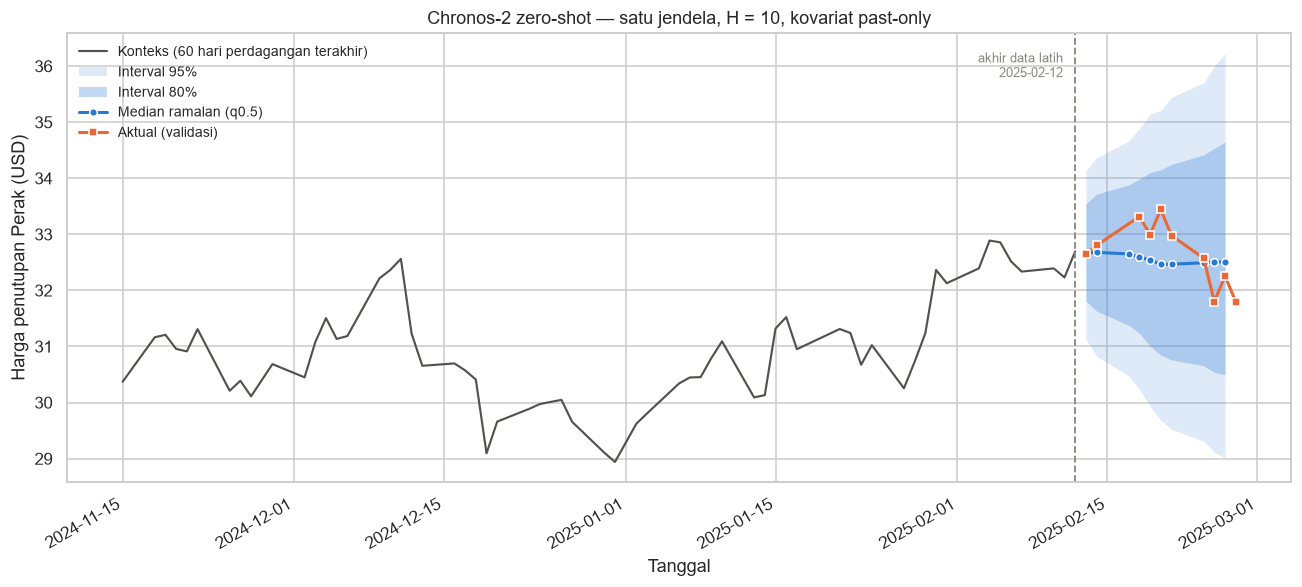

Tersimpan: D:\project-skripsi\results\figures\smoke_test_one_window.png

Tanggal beririsan: 9 dari 10
MAE pada tanggal beririsan : 0.4283
(angka indikatif untuk satu jendela; evaluasi resmi memakai src/evaluation.py)


In [14]:
CONTEXT_DAYS = 60
COLOR_CONTEXT = "#52514e"
COLOR_MEDIAN = "#2a78d6"
COLOR_ACTUAL = "#eb6834"

context_tail = train[TARGET_COL].iloc[-CONTEXT_DAYS:]
forecast = prediction.loc[CONFIG["model"]["item_id"]]
forecast_dates = forecast.index
actual_window = val[TARGET_COL].iloc[:HORIZON]

fig, ax = plt.subplots(figsize=(12, 5.5))

ax.plot(context_tail.index, context_tail.to_numpy(), color=COLOR_CONTEXT,
        linewidth=1.4, label=f"Konteks ({CONTEXT_DAYS} hari perdagangan terakhir)")

ax.fill_between(forecast_dates, forecast["0.025"], forecast["0.975"],
                color=COLOR_MEDIAN, alpha=0.15, linewidth=0, label="Interval 95%")
ax.fill_between(forecast_dates, forecast["0.1"], forecast["0.9"],
                color=COLOR_MEDIAN, alpha=0.28, linewidth=0, label="Interval 80%")
ax.plot(forecast_dates, forecast["0.5"], color=COLOR_MEDIAN, linewidth=2.0,
        marker="o", markersize=5, markeredgecolor="white", markeredgewidth=1.0,
        label="Median ramalan (q0.5)")

ax.plot(actual_window.index, actual_window.to_numpy(), color=COLOR_ACTUAL,
        linewidth=2.0, marker="s", markersize=5, markeredgecolor="white",
        markeredgewidth=1.0, label="Aktual (validasi)")

# Batas antara konteks dan periode ramalan
boundary = train.index[-1]
ax.axvline(boundary, color="#898781", linestyle="--", linewidth=1.2)
ax.annotate("akhir data latih\n" + str(boundary.date()),
            xy=(boundary, ax.get_ylim()[1]), xytext=(-8, -12),
            textcoords="offset points", ha="right", va="top",
            fontsize=8.5, color="#898781")

ax.set_xlabel("Tanggal")
ax.set_ylabel("Harga penutupan Perak (USD)")
ax.set_title(
    f"Chronos-2 zero-shot — satu jendela, H = {HORIZON}, kovariat past-only",
    fontsize=12,
)
ax.legend(frameon=False, fontsize=9, loc="upper left")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "smoke_test_one_window.png")
plt.show()

print("Tersimpan:", FIGURES_DIR / "smoke_test_one_window.png")

# Galat kasar pada tanggal yang benar-benar beririsan
aligned = forecast["0.5"].reindex(actual_window.index).dropna()
common = actual_window.loc[aligned.index]
print()
print(f"Tanggal beririsan: {len(aligned)} dari {HORIZON}")
print(f"MAE pada tanggal beririsan : {np.abs(common - aligned).mean():.4f}")
print("(angka indikatif untuk satu jendela; evaluasi resmi memakai src/evaluation.py)")

## 9. Temuan API — spesifikasi untuk `src/forecasting.py`

Bagian ini adalah keluaran terpenting notebook. Empat temuan pertama **berbeda dari dugaan awal** dan wajib ditangani; sisanya catatan yang perlu diikuti.

---

### T1 — `freq` tidak dapat disimpulkan; `fit()` menolak berjalan

`TimeSeriesDataFrame.freq` bernilai `None` karena hari perdagangan tidak berjarak tetap. Memanggil `fit()` langsung menghasilkan:

```
ValueError: Frequency of train_data is not provided and cannot be inferred.
```

**Penanganan.** Panggil `.convert_frequency(freq="B")` dan buat predictor dengan `freq="B"`. Pada data latih, konversi ini menyisipkan **34 baris NaN dari 913** (3,72%) yang seluruhnya adalah hari libur bursa.

Baris NaN **tidak melanggar aturan penyelarasan tanggal**. Yang dilarang adalah nilai target hasil *forward fill*, karena menciptakan segmen datar buatan yang menaikkan akurasi secara semu. NaN justru menyatakan "tidak ada observasi" secara jujur, dan Chronos-2 memang dirancang menangani nilai hilang. Yang wajib dijaga: **tanggal NaN tidak boleh ikut dinilai** saat evaluasi.

### T2 — Kalender prediksi tidak sejajar dengan kalender aktual

Dengan `freq="B"`, `prediction_length=10` menghasilkan 10 **hari bisnis**, bukan 10 **hari perdagangan**. Pada jendela yang diuji, ramalan memuat 2025-02-17 (Presidents' Day, bursa tutup) tetapi tidak menjangkau 2025-02-27 yang justru punya nilai aktual — hanya **9 dari 10** tanggal beririsan.

**Penanganan.** Ramalkan lebih panjang, lalu ambil H tanggal pertama yang benar-benar merupakan hari perdagangan:

- `prediction_length = H` menutupi hanya **65,09%** jendela,
- `prediction_length = H + 1` menutupi **98,01%**,
- **`prediction_length = H + 2` menutupi 100,00%** jendela.

Jadi `src/forecasting.py` harus memakai `prediction_length = H + 2`, lalu me-*reindex* hasilnya ke tanggal aktual dan mengambil H baris pertama. Penyejajaran **wajib berdasarkan timestamp**, bukan posisi baris — inilah jebakan paling berbahaya di seluruh pipeline, karena kesalahannya tidak menimbulkan error, hanya angka yang salah.

### T3 — `fine_tune_mode="linear_probe"` TIDAK VALID

Docstring `Chronos2Model` menyatakan hanya ada dua pilihan:

```
fine_tune_mode : str, default = "lora"
    Fine-tuning mode, either "full" for full fine-tuning or "lora" for
    Low Rank Adaptation (LoRA).
```

Padahal `config/config.yaml` saat ini menuliskan `fine_tune_mode: ["full", "linear_probe"]`. Nilai `"linear_probe"` akan ditolak. **Config wajib diperbaiki menjadi `["full", "lora"]`** sebelum modul fine-tuning ditulis.

### T4 — `random_seed` bawaan adalah 123, bukan 42

Baik `fit()` maupun `predict()` memiliki `random_seed: int | None = 123`. Tuntutan reproducibility penelitian ini mensyaratkan seed 42, sehingga **`random_seed=CONFIG["seed"]` wajib diteruskan secara eksplisit pada kedua pemanggilan** — tidak cukup hanya di `fit()`.

---

### Catatan teknis lain

| Hal | Temuan |
|---|---|
| Kunci `hyperparameters` | `"Chronos2"` (alias `"Chronos2Model"` juga diterima) |
| Preset predictor | `"chronos2"`, `"chronos2_small"`, `"chronos2_ensemble"` tersedia — sesuai `model_preset` di config |
| Bentuk keluaran `predict()` | `TimeSeriesDataFrame` berbentuk `(prediction_length, 14)` |
| Kolom keluaran | `'mean'` **ditambah** 13 kuantil; nama kolom kuantil berupa **string** (`'0.025'`, …), bukan float |
| Kolom `mean` | Bukan kuantil — wajib dikeluarkan sebelum menghitung *crossing rate* |
| Urutan kuantil | 0 pelanggaran pada jendela uji ini; tetap harus diukur di seluruh jendela |
| `context_length` | Nama hyperparameter untuk `max_context` pada config (bawaan Chronos-2: 8192) |
| `cross_learning` | Bawaannya `True`; untuk satu deret tunggal, `False` di config sudah tepat |
| Dukungan kovariat | `_supports_past_covariates=True`, `_supports_known_covariates=True`, `_supports_static_features=False` |
| Ablasi oracle / ex-post | Tersedia lewat `disable_past_covariates` / `disable_known_covariates` |
| `skip_model_selection=True` | Diperlukan untuk zero-shot murni: mencegah pemotongan data validasi internal dan pembentukan ensemble |

### Perangkat keras dan waktu eksekusi

`torch.cuda.is_available()` bernilai `False`, tetapi penyebabnya **bukan** ketiadaan GPU: `torch.version.cuda` bernilai `None`, artinya build torch yang terpasang adalah varian **CPU-only**. Bila mesin ini memiliki GPU NVIDIA (periksa dengan `nvidia-smi`), memasang ulang torch versi CUDA akan langsung mengaktifkannya tanpa mengubah satu baris kode pun — Chronos-2 memilih perangkat secara otomatis.

Dengan CPU, `predict()` mantap di kisaran **2,1 detik** per jendela setelah bobot termuat (pengukuran berulang pada notebook ini: 2,10–2,16 s; pada mesin yang sedang terbebani sempat terukur 2,7 s). Ekstrapolasinya sekitar **6,4 menit** untuk 181 jendela periode uji dan **12,8 menit** untuk validasi + uji sekaligus. **Zero-shot tidak memerlukan Colab.**

Yang menjadi masalah adalah **fine-tuning**. Grid pada config memuat 18 kombinasi (3 laju belajar × 3 jumlah langkah × 2 mode), dengan sampai 1.000 langkah gradien per kombinasi. Beban ini berbeda kelas dari inferensi dan akan sangat lambat di CPU. Tiga pilihan, berurutan dari yang paling disarankan:

1. **Pasang torch versi CUDA** dan pakai GPU lokal — tidak mengubah kode sama sekali, dan menjaga seluruh pipeline tetap reproducible di satu mesin.
2. **Jalankan tahap fine-tuning di Colab** dengan GPU, lalu unduh model hasilnya. Konsekuensinya versi library di Colab wajib dicatat terpisah agar hasilnya tetap dapat direproduksi.
3. **Perkecil grid** — mode `"lora"` (bawaan) jauh lebih ringan daripada `"full"`, dan `fine_tune_steps` dapat dipangkas. Ini menurunkan biaya tetapi juga kekuatan klaim penelitian.

Keputusan ini perlu diambil **sebelum** `src/forecasting.py` ditulis, karena menentukan apakah modul tersebut harus mendukung pemisahan tahap fit dan predict lintas mesin.